In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [ ]:
# Base dataset
df = pd.read_csv("../../Data/Processed/renttherunway_clean.csv")

# GMM clusters
gmm = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/gmm_df.csv")[["user_id", "item_id", "body_cluster", "cluster_confidence"]]

# DBSCAN clusters
dbscan = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/dbscan_df.csv")[["user_id", "dbscan_cluster"]]

# K-Means clusters
kmeans = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/kmeans_clusters.csv").rename(columns={"cluster": "kmeans_cluster"})

# LDA topic features
lda = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv")

In [3]:
df = df.merge(
    dbscan,
    on="user_id",
    how="left"
)

In [4]:
df = df.merge(
    gmm,
    on=["user_id", "item_id"],
    how="left"
)

In [5]:
df = df.merge(
    kmeans,
    on=["user_id", "item_id"],
    how="left"
)

In [6]:
df = df.merge(
    lda,
    on=["user_id", "item_id", "fit", "fit_label"],
    how="left"
)

In [7]:
df["is_outlier"] = (df["dbscan_cluster"] == -1).astype(int)

In [8]:
NUMERIC_FEATURES = [
    "height_inches",
    "weight_lbs",
    "bmi",
    "age",
    "bust_band",
    "cup_size_num"
]

CLUSTER_FEATURES = [
    "dbscan_cluster",
    "body_cluster",
    "kmeans_cluster"
]

BINARY_FEATURES = ["is_outlier"]

TOPIC_FEATURES = [c for c in df.columns if c.startswith("topic_")]

In [9]:
X = df[
    NUMERIC_FEATURES
    + CLUSTER_FEATURES
    + BINARY_FEATURES
    + TOPIC_FEATURES
]

y = df["fit_label"].astype(int)

In [10]:
assert y.notna().all()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        # Numeric + topic features
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            NUMERIC_FEATURES + TOPIC_FEATURES
        ),

        # Cluster features (categorical)
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CLUSTER_FEATURES
        ),

        # Binary features
        (
            "bin",
            SimpleImputer(strategy="constant", fill_value=0),
            BINARY_FEATURES
        )
    ],
    remainder="drop"
)

In [13]:
rf = RandomForestClassifier(
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

In [14]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", rf)
])

In [15]:
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [6, 8, 12],
    "model__min_samples_leaf": [100, 200]
}

In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [17]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END model__max_depth=6, model__min_samples_leaf=200, model__n_estimators=50; total time=  59.4s
[CV] END model__max_depth=6, model__min_samples_leaf=100, model__n_estimators=50; total time= 1.1min
[CV] END model__max_depth=6, model__min_samples_leaf=100, model__n_estimators=50; total time= 1.1min
[CV] END model__max_depth=6, model__min_samples_leaf=100, model__n_estimators=50; total time= 1.1min
[CV] END model__max_depth=6, model__min_samples_leaf=100, model__n_estimators=50; total time= 1.1min
[CV] END model__max_depth=6, model__min_samples_leaf=100, model__n_estimators=50; total time= 1.2min
[CV] END model__max_depth=6, model__min_samples_leaf=200, model__n_estimators=50; total time= 1.2min
[CV] END model__max_depth=6, model__min_samples_leaf=200, model__n_estimators=50; total time= 1.3min
[CV] END model__max_depth=6, model__min_samples_leaf=200, model__n_estimators=50; total time= 1.3min
[CV] END model__max_depth=6, m

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [6, 8, ...], 'model__min_samples_leaf': [100, 200], 'model__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each 

In [18]:
best_rf = grid.best_estimator_

y_test_pred = best_rf.predict(X_test)

print("Best Random Forest parameters:")
print(grid.best_params_)

print("\nRandom Forest — Test Set Performance")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Small", "Fit", "Large"]
))

Best Random Forest parameters:
{'model__max_depth': 12, 'model__min_samples_leaf': 100, 'model__n_estimators': 50}

Random Forest — Test Set Performance
              precision    recall  f1-score   support

       Small       0.44      0.77      0.56     34494
         Fit       0.88      0.79      0.84    174054
       Large       0.78      0.66      0.71     57738

    accuracy                           0.76    266286
   macro avg       0.70      0.74      0.70    266286
weighted avg       0.80      0.76      0.77    266286



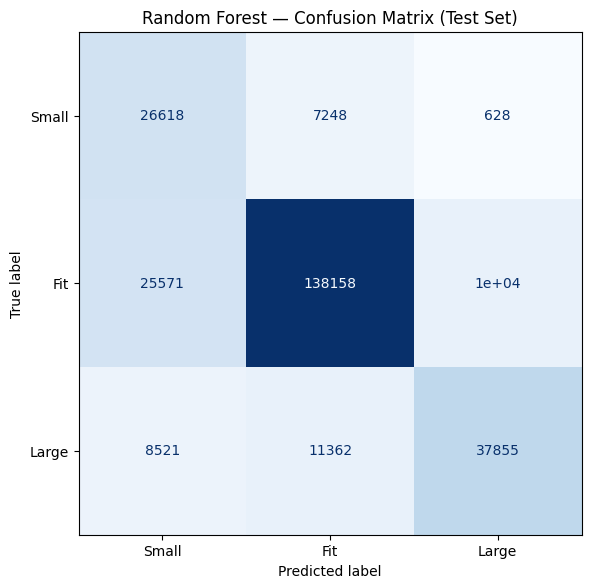

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Small", "Fit", "Large"],
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Random Forest — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("../../Figures/Supervised_Outputs/random_forest_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
rf_proba = best_rf.predict_proba(X_test)

rf_proba_df = pd.DataFrame({
    "user_id": df.loc[X_test.index, "user_id"],
    "item_id": df.loc[X_test.index, "item_id"],
    "true_fit": y_test.values,
    "prob_small": rf_proba[:, 0],
    "prob_fit": rf_proba[:, 1],
    "prob_large": rf_proba[:, 2]
})

rf_proba_df.to_csv(
    "../../Data/Processed/Supervised_Outputs/random_forest_fit_probabilities.csv",
    index=False
)

In [ ]:
import joblib

joblib.dump(
    best_rf,
    "../../Models/random_forest_fit_classifier.joblib"
)

['../Models/random_forest_fit_classifier.joblib']

In [22]:
# After fitting
prep = best_rf.named_steps["prep"]

feature_names = []

# Numeric + topic features
feature_names.extend(NUMERIC_FEATURES + TOPIC_FEATURES)

# Cluster features (after one-hot)
cat_encoder = prep.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = cat_encoder.get_feature_names_out(CLUSTER_FEATURES)
feature_names.extend(cat_feature_names)

# Binary features
feature_names.extend(BINARY_FEATURES)

In [23]:
importances = best_rf.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

In [ ]:
importance_df.head(20).to_csv(
    "../../Data/Processed/Supervised_Outputs/random_forest_feature_importances.csv",
    index=False
)

# Random Forest Classifier Overview

### Overview
A Random Forest classifier was trained and evaluated on a clothing fit classification task, predicting whether an item fits as Small, Fit, or Large. Hyperparameters were selected via 5-fold stratified cross-validation, yielding optimal parameters of max_depth=12, min_samples_leaf=100, and n_estimators=50.

### Overall Performance
The model achieved 76% accuracy on the test set of 266,286 samples, with a weighted F1-score of 0.77. Performance is broadly comparable to the Bagging classifier, which is expected given their shared tree-based structure — the key difference being that Random Forest additionally randomizes feature selection at each split to reduce correlation between trees.

### Class-Level Analysis
**Fit (Majority Class)**
Strong performance with 0.88 precision and 0.79 recall (F1 = 0.84). Of 174,054 true Fit samples, 138,158 were correctly classified. The primary error mode is Fit items predicted as Small (25,571 cases), mirroring the pattern seen in Bagging.

**Small (Minority Class)**
The model's weakest class, with 0.44 precision and 0.77 recall (F1 = 0.56). While recall is decent — catching 26,618 of 34,494 true Small items — precision is poor, meaning a large share of items predicted as Small are actually Fit or Large. This is a direct consequence of class imbalance and the model casting a wide net for the minority class.

**Large**
Moderate performance with 0.78 precision and 0.66 recall (F1 = 0.71). Of 57,738 true Large samples, 37,855 were correctly identified. Errors split roughly between Fit (11,362) and Small (8,521) predictions, suggesting the model struggles most at the boundaries between size categories.

### Comparison to Other Models
Random Forest performs similarly to Bagging on Fit and Small, but falls slightly behind on Large (F1 0.71 vs. 0.75). Both tree-based ensembles are substantially outperformed by KNN across all classes, particularly on precision for Small and recall for Large. The Random Forest's feature subsampling does not appear to provide a meaningful advantage over Bagging on this dataset.